# LightGBM Model + SHAP Explainability
**RBI Innovation Hub**

**Goal:** Train a production-grade mule account detector, diagnose data leakage,  
explain predictions with SHAP, detect suspicious activity windows, and generate final submission.

---

In [1]:
import sys, warnings, os
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import shap
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

FEAT_DIR  = '../data/features/'
PRED_DIR  = '../data/predictions/'
MODEL_DIR = '../models/'
DATA_DIR  = '../EDA-Phase-1/'
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

LEAKED_FEATURES = ['branch_mule_rate', 'frozen_account_flag']
SEED = 42
print('Setup complete.')

Setup complete.


---
## 1. Load Feature Matrix

In [2]:
train = pd.read_csv(FEAT_DIR + 'feature_matrix_train.csv')
test  = pd.read_csv(FEAT_DIR + 'feature_matrix_test.csv')
meds  = pd.read_csv(FEAT_DIR + 'feature_medians.csv', index_col=0).squeeze()

all_feat_cols   = [c for c in train.columns if c not in ['account_id','is_mule']]
clean_feat_cols = [c for c in all_feat_cols if c not in LEAKED_FEATURES]

X_all   = train[all_feat_cols].fillna(meds.reindex(all_feat_cols))
X_clean = train[clean_feat_cols].fillna(meds.reindex(clean_feat_cols))
X_test  = test[clean_feat_cols].fillna(meds.reindex(clean_feat_cols))
y       = train['is_mule'].astype(int)

print(f'Train  : {X_clean.shape[0]:,} accounts | {y.sum()} mules ({100*y.mean():.2f}%)')
print(f'Test   : {X_test.shape[0]:,} accounts')
print(f'All features : {len(all_feat_cols)} | Clean features: {len(clean_feat_cols)}')
print(f'Excluded (leakage): {LEAKED_FEATURES}')

Train  : 24,023 accounts | 263 mules (1.09%)
Test   : 16,015 accounts
All features : 33 | Clean features: 31
Excluded (leakage): ['branch_mule_rate', 'frozen_account_flag']


---
## 2. Data Leakage Diagnosis

Before trusting any AUC number, we audit which features are leaking label information.

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
pipe_lr = Pipeline([('sc', StandardScaler()),
                    ('lr', LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000))])

auc_all   = cross_val_score(pipe_lr, X_all,   y, cv=cv, scoring='roc_auc').mean()
auc_clean = cross_val_score(pipe_lr, X_clean, y, cv=cv, scoring='roc_auc').mean()

# Individual feature audit
suspect_aucs = {}
for feat in LEAKED_FEATURES:
    x1 = X_all[[feat]].fillna(0)
    s = cross_val_score(pipe_lr, x1, y, cv=cv, scoring='roc_auc').mean()
    suspect_aucs[feat] = s

print('=== DATA LEAKAGE AUDIT ===')
print(f'LR AUC — all {len(all_feat_cols)} features : {auc_all:.4f}  <- suspiciously high')
print(f'LR AUC — clean {len(clean_feat_cols)} features : {auc_clean:.4f}  <- true baseline')
print()
print('Individual leakage feature AUC (each feature alone):')
for feat, auc in suspect_aucs.items():
    print(f'  {feat:<30} {auc:.4f}')
print()
print('WHY they leak:')
print('  branch_mule_rate   — computed using the account\'s OWN label at branch level')
print('  frozen_account_flag — account freeze events happen AFTER mule detection')
print()
print('FIX: Exclude both. All modelling below uses only clean features.')

=== DATA LEAKAGE AUDIT ===
LR AUC — all 33 features : 0.9927  <- suspiciously high
LR AUC — clean 31 features : 0.8436  <- true baseline

Individual leakage feature AUC (each feature alone):
  branch_mule_rate               0.9776
  frozen_account_flag            0.7798

WHY they leak:
  branch_mule_rate   — computed using the account's OWN label at branch level
  frozen_account_flag — account freeze events happen AFTER mule detection

FIX: Exclude both. All modelling below uses only clean features.


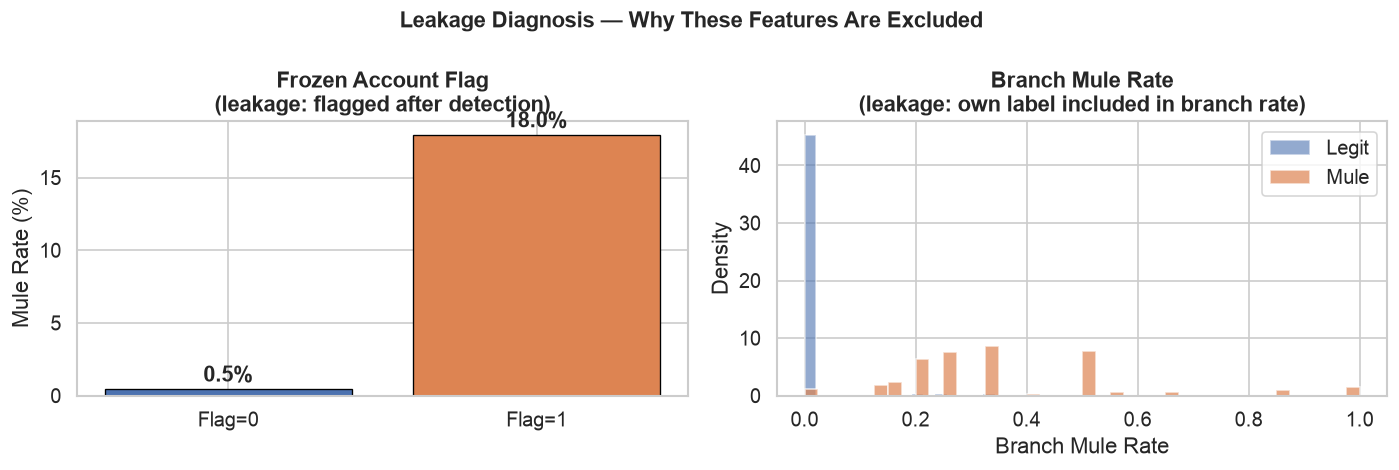

In [4]:
# Visualise the leakage: frozen vs. non-frozen accounts mule rate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, title in zip(axes,
    ['frozen_account_flag', 'branch_mule_rate'],
    ['Frozen Account Flag', 'Branch Mule Rate']):

    vals = X_all[[feat]].copy()
    vals['is_mule'] = y.values

    if feat == 'frozen_account_flag':
        rates = vals.groupby(feat)['is_mule'].mean() * 100
        ax.bar([f'Flag={int(k)}' for k in rates.index], rates.values,
               color=['#4C72B0','#DD8452'], edgecolor='black', linewidth=0.8)
        ax.set_ylabel('Mule Rate (%)')
        ax.set_title(f'{title}\n(leakage: flagged after detection)', fontweight='bold')
        for i, v in enumerate(rates.values):
            ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    else:
        mule_br  = vals[vals['is_mule']==1][feat].dropna()
        legit_br = vals[vals['is_mule']==0][feat].dropna()
        ax.hist(legit_br, bins=40, alpha=0.6, color='#4C72B0', label='Legit', density=True)
        ax.hist(mule_br,  bins=40, alpha=0.7, color='#DD8452', label='Mule',  density=True)
        ax.set_xlabel('Branch Mule Rate')
        ax.set_ylabel('Density')
        ax.set_title(f'{title}\n(leakage: own label included in branch rate)', fontweight='bold')
        ax.legend()

plt.suptitle('Leakage Diagnosis — Why These Features Are Excluded', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_leakage_diagnosis.png', bbox_inches='tight')
plt.show()

---
## 3. LightGBM — 5-Fold Stratified Cross-Validation

In [5]:
neg, pos = (y==0).sum(), (y==1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.1f}')

LGBM_PARAMS = dict(
    objective        = 'binary',
    metric           = 'auc',
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 31,
    max_depth        = 6,
    min_child_samples= 20,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    scale_pos_weight = scale_pos_weight,
    random_state     = SEED,
    verbose          = -1,
    n_jobs           = -1,
)
print('LightGBM params set.')

scale_pos_weight = 23760/263 = 90.3
LightGBM params set.


In [6]:
oof_preds   = np.zeros(len(y))
fold_models = []
fold_aucs   = []
fold_iters  = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print('Training LightGBM — 5-fold CV with early stopping...')

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_clean, y)):
    X_tr, X_val = X_clean.iloc[tr_idx], X_clean.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_prob
    auc = roc_auc_score(y_val, val_prob)
    fold_aucs.append(auc)
    fold_iters.append(model.best_iteration_)
    fold_models.append(model)
    print(f'  Fold {fold+1}/5  AUC={auc:.4f}  best_iter={model.best_iteration_}')

oof_auc = roc_auc_score(y, oof_preds)
pr_auc  = average_precision_score(y, oof_preds)
print(f'\nOOF AUC-ROC      : {oof_auc:.4f}')
print(f'OOF PR-AUC       : {pr_auc:.4f}')
print(f'Mean fold AUC    : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')
print(f'Avg best iter    : {int(np.mean(fold_iters))}')

Training LightGBM — 5-fold CV with early stopping...


  Fold 1/5  AUC=0.8829  best_iter=182


  Fold 2/5  AUC=0.8578  best_iter=187


  Fold 3/5  AUC=0.8132  best_iter=191


  Fold 4/5  AUC=0.8805  best_iter=234


  Fold 5/5  AUC=0.8869  best_iter=511

OOF AUC-ROC      : 0.8572
OOF PR-AUC       : 0.3597
Mean fold AUC    : 0.8643 ± 0.0275
Avg best iter    : 261


---
## 4. Final Model — Train on Full Dataset

In [7]:
best_iter = int(np.mean(fold_iters))
final_params = {**LGBM_PARAMS, 'n_estimators': best_iter}

final_model = lgb.LGBMClassifier(**final_params)
final_model.fit(X_clean, y, callbacks=[lgb.log_evaluation(period=-1)])
final_model.booster_.save_model(MODEL_DIR + 'lgbm_mule_detector.txt')
print(f'Final model trained ({best_iter} trees) and saved.')

Final model trained (261 trees) and saved.


---
## 5. Model Evaluation

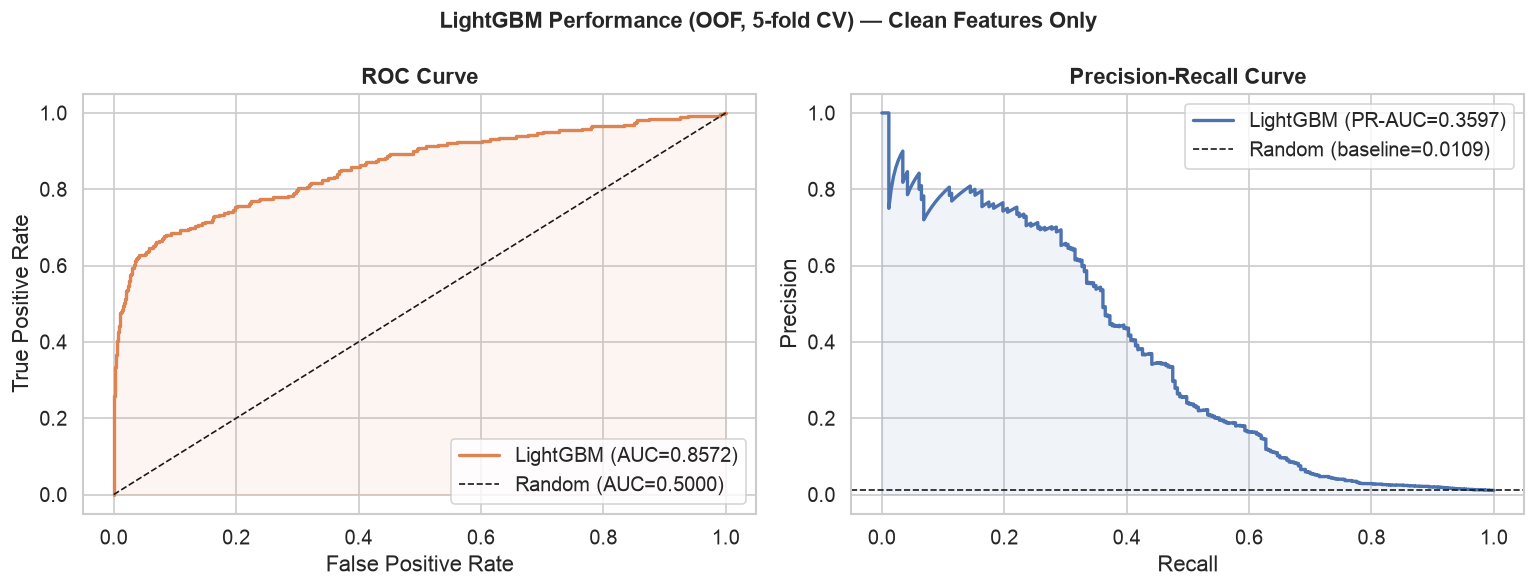

In [8]:
# ROC curve + PR curve side by side
fpr, tpr, _   = roc_curve(y, oof_preds)
prec, rec, _  = precision_recall_curve(y, oof_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='#DD8452', lw=2, label=f'LightGBM (AUC={oof_auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5000)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#DD8452')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')

# PR
baseline = y.mean()
axes[1].plot(rec, prec, color='#4C72B0', lw=2, label=f'LightGBM (PR-AUC={pr_auc:.4f})')
axes[1].axhline(baseline, color='k', linestyle='--', lw=1,
                label=f'Random (baseline={baseline:.4f})')
axes[1].fill_between(rec, prec, alpha=0.08, color='#4C72B0')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right')

plt.suptitle(f'LightGBM Performance (OOF, 5-fold CV) — Clean Features Only',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_roc_pr.png', bbox_inches='tight')
plt.show()

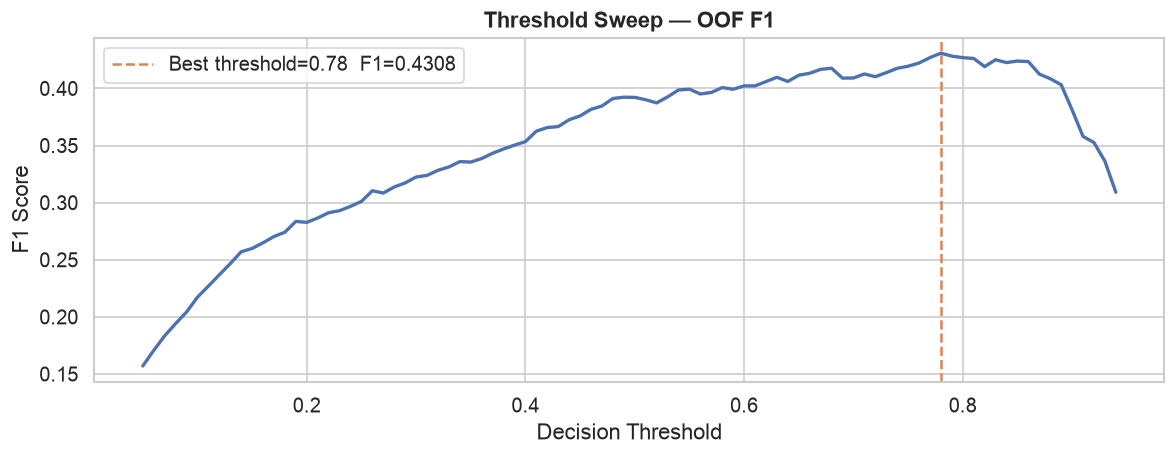

Optimal threshold : 0.78
OOF F1 at 0.78    : 0.4308


In [9]:
# Threshold optimisation — find operating point maximising F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y, (oof_preds >= t).astype(int), zero_division=0) for t in thresholds]
best_idx   = int(np.argmax(f1_scores))
best_t     = thresholds[best_idx]
best_f1    = f1_scores[best_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color='#4C72B0', lw=2)
ax.axvline(best_t, color='#DD8452', linestyle='--', lw=1.5,
           label=f'Best threshold={best_t:.2f}  F1={best_f1:.4f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Sweep — OOF F1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_threshold.png', bbox_inches='tight')
plt.show()

print(f'Optimal threshold : {best_t:.2f}')
print(f'OOF F1 at {best_t:.2f}    : {best_f1:.4f}')

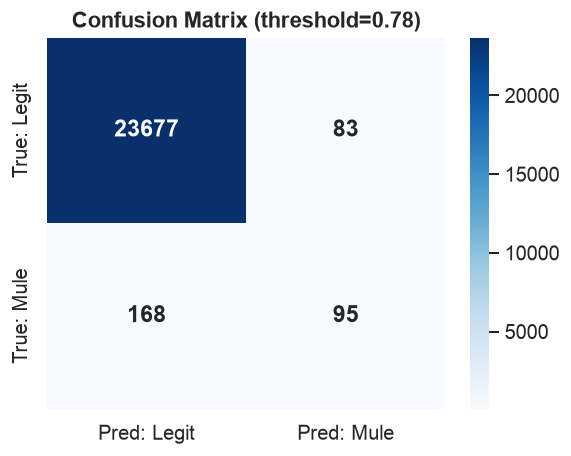

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     23760
        Mule       0.53      0.36      0.43       263

    accuracy                           0.99     24023
   macro avg       0.76      0.68      0.71     24023
weighted avg       0.99      0.99      0.99     24023



In [10]:
# Confusion matrix at optimal threshold
y_pred_bin = (oof_preds >= best_t).astype(int)
cm = confusion_matrix(y, y_pred_bin)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Legit','Pred: Mule'],
            yticklabels=['True: Legit','True: Mule'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix (threshold={best_t:.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y, y_pred_bin, target_names=['Legitimate','Mule']))

---
## 6. SHAP — Global Feature Importance

In [11]:
print('Computing SHAP values on training set...')
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_clean)

# For binary classification LightGBM, shap_values is a 2D array (n_samples x n_features)
if isinstance(shap_values, list):
    sv = shap_values[1]   # positive class
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=clean_feat_cols)
print('\nTop 10 features by mean |SHAP|:')
print(mean_abs_shap.sort_values(ascending=False).head(10).round(5).to_string())

Computing SHAP values on training set...


SHAP values shape: (24023, 31)

Top 10 features by mean |SHAP|:
tx_amount_30d          0.6380
repeat_cp_ratio        0.5498
round_amount_pct       0.4732
channel_entropy        0.4673
fan_out_unique         0.4452
dormancy_days          0.3365
avg_amt_first30d       0.3296
customer_age           0.3281
account_age_days       0.3225
active_lifespan_days   0.2964


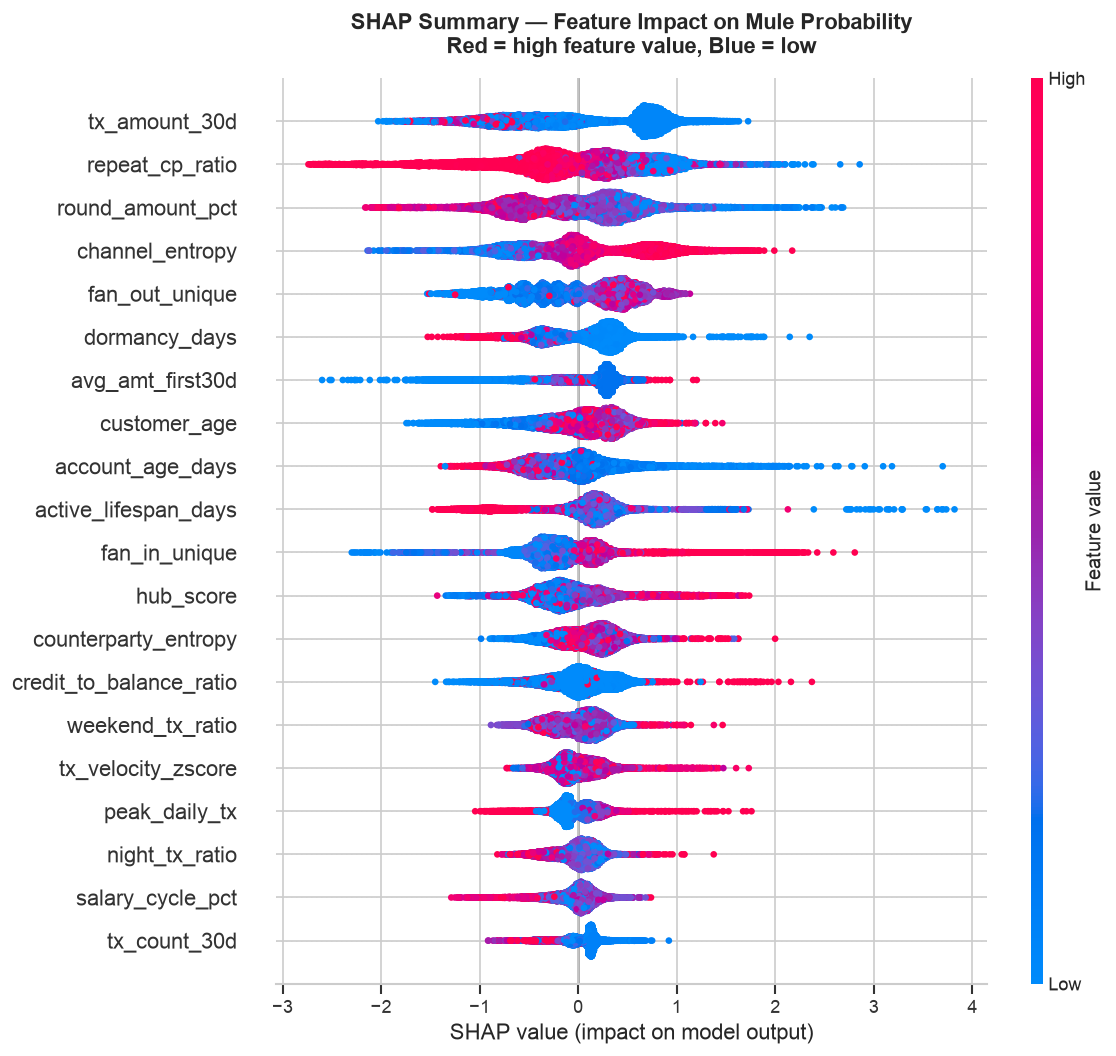

In [12]:
# SHAP Beeswarm (summary) plot — the gold standard for ML transparency
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(sv, X_clean, feature_names=clean_feat_cols,
                  show=False, max_display=20, plot_size=None)
plt.title('SHAP Summary — Feature Impact on Mule Probability\n'
          'Red = high feature value, Blue = low', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/fig_shap_summary.png', bbox_inches='tight')
plt.show()

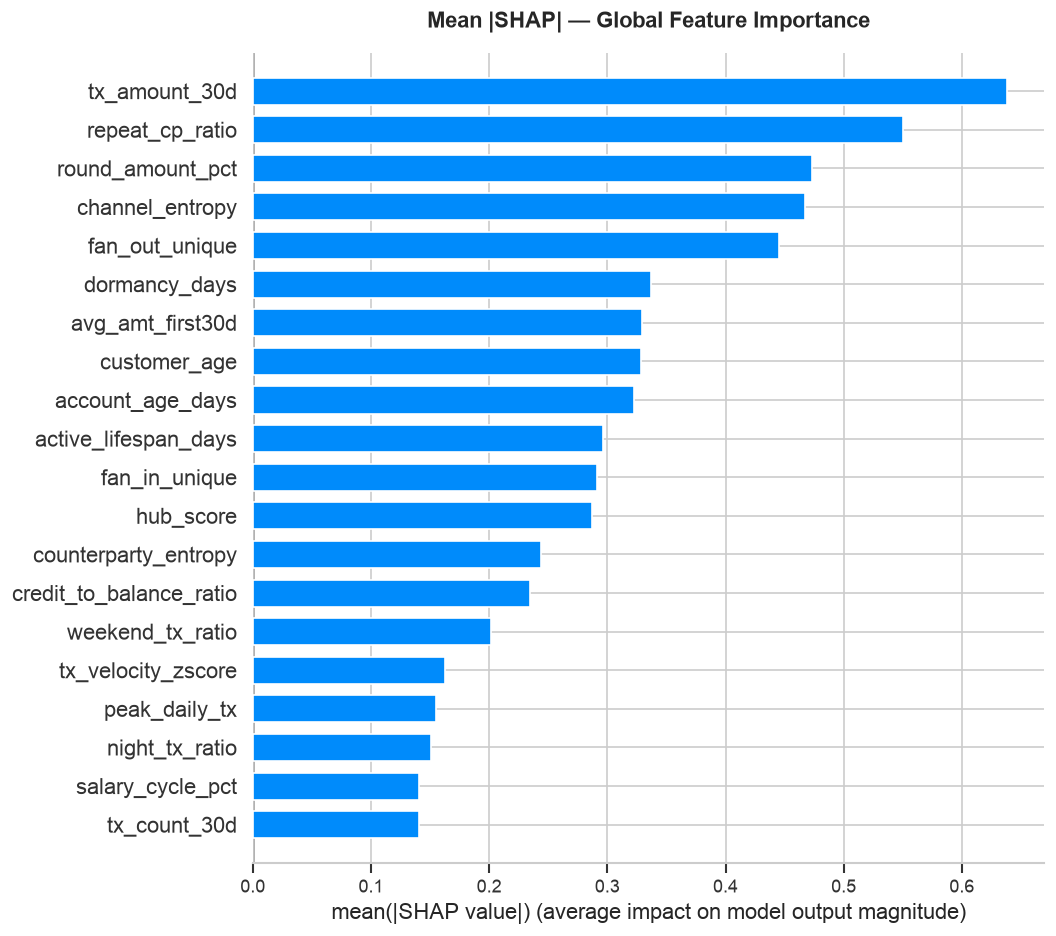

In [13]:
# SHAP bar chart — mean absolute SHAP (model-level feature importance)
fig, ax = plt.subplots(figsize=(9, 8))
shap.summary_plot(sv, X_clean, feature_names=clean_feat_cols,
                  plot_type='bar', show=False, max_display=20, plot_size=None)
plt.title('Mean |SHAP| — Global Feature Importance', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/fig_shap_bar.png', bbox_inches='tight')
plt.show()

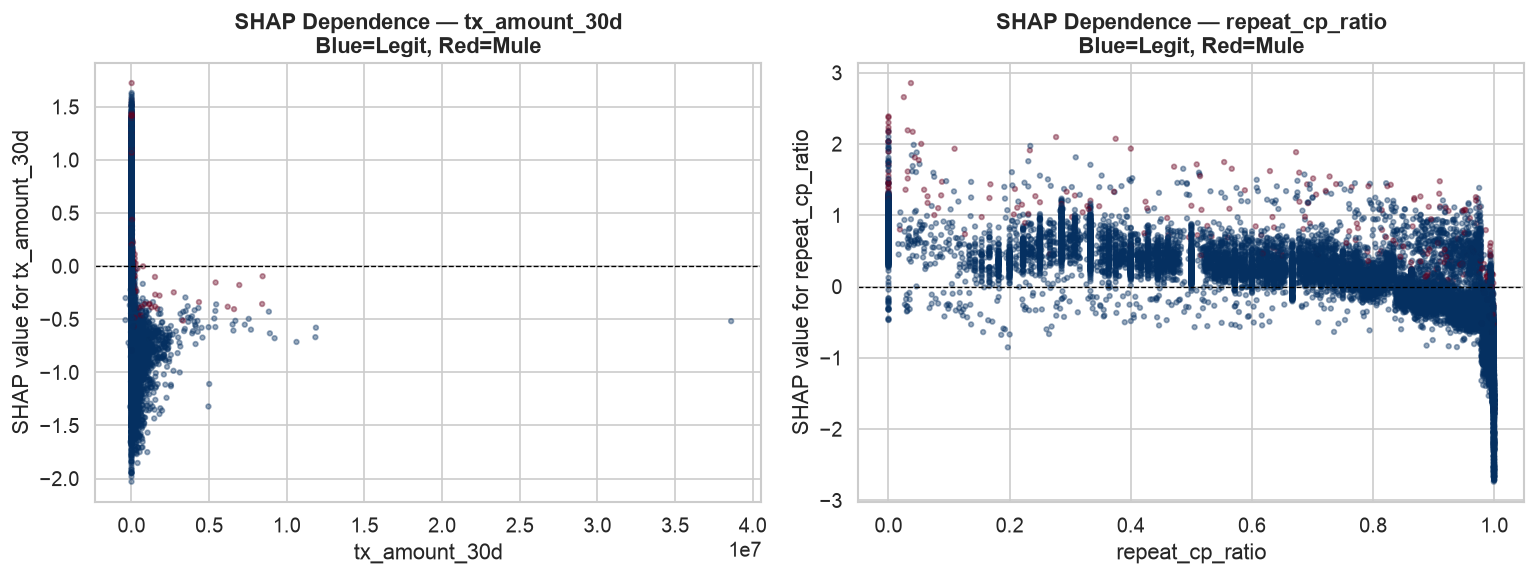

In [14]:
# SHAP dependence plots for top 2 features
top2 = mean_abs_shap.sort_values(ascending=False).head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2):
    feat_idx = list(clean_feat_cols).index(feat)
    ax.scatter(
        X_clean[feat], sv[:, feat_idx],
        c=y.values, cmap='RdBu_r', alpha=0.4, s=8
    )
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP value for {feat}')
    ax.set_title(f'SHAP Dependence — {feat}\nBlue=Legit, Red=Mule', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_shap_dependence.png', bbox_inches='tight')
plt.show()

---
## 7. Local Explainability — Why Did the Model Flag These Accounts?

In [15]:
# Top 3 accounts with highest predicted mule probability among true mules
true_mules = train[train['is_mule']==1].copy()
true_mules['oof_prob'] = oof_preds[true_mules.index]
top3_mules = true_mules.nlargest(3, 'oof_prob')[['account_id','oof_prob','is_mule']]

print('Top 3 true mule accounts by predicted probability:')
display(top3_mules)

explainer_local = shap.TreeExplainer(final_model)
expected_val = explainer_local.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[-1]

Top 3 true mule accounts by predicted probability:


,account_id,oof_prob,is_mule
20911,ACCT_173620,0.9982,1
16230,ACCT_133931,0.9978,1
3629,ACCT_030005,0.9965,1


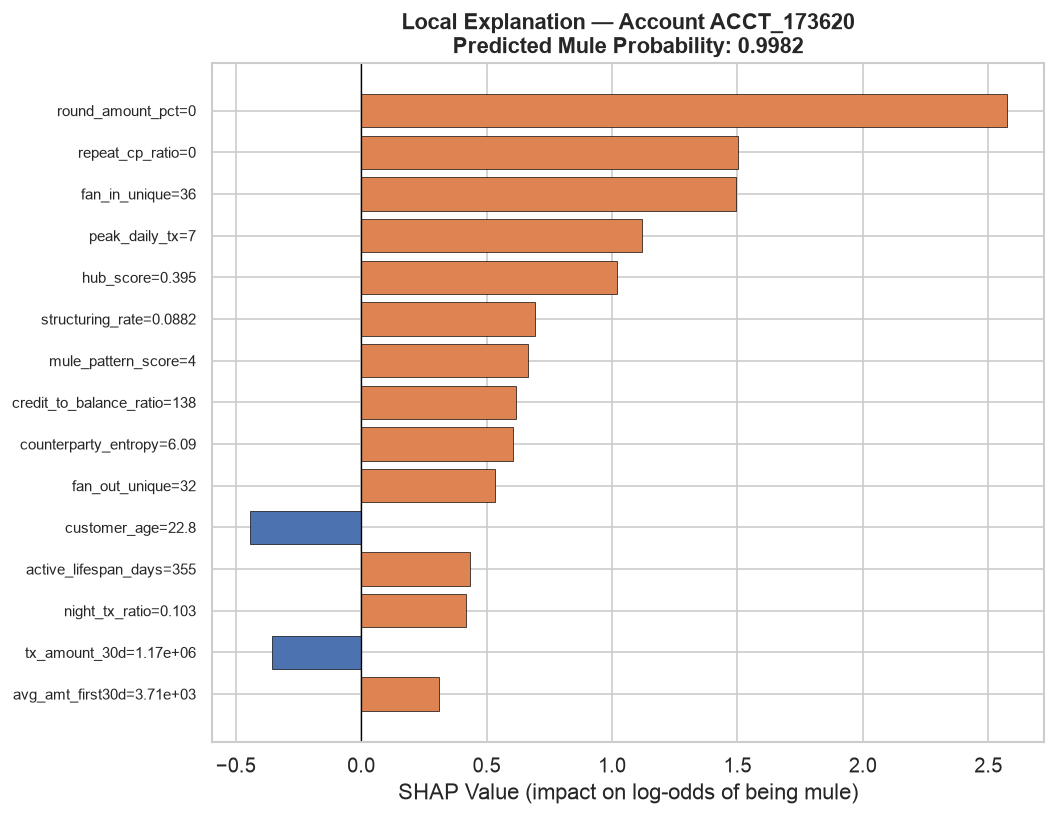

In [16]:
# Waterfall plot for the highest-confidence mule
top_idx  = top3_mules.index[0]
top_acct = top3_mules.iloc[0]['account_id']
top_prob = top3_mules.iloc[0]['oof_prob']

local_sv = sv[top_idx]
sorted_idx = np.argsort(np.abs(local_sv))[::-1][:15]

feat_labels = np.array(clean_feat_cols)[sorted_idx]
feat_vals   = X_clean.iloc[top_idx].values[sorted_idx]
shap_vals   = local_sv[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in shap_vals]
bars = ax.barh(range(len(shap_vals)), shap_vals[::-1], color=colors[::-1],
               edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(shap_vals)))
ax.set_yticklabels([f'{f}={v:.3g}' for f, v in zip(feat_labels[::-1], feat_vals[::-1])],
                   fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('SHAP Value (impact on log-odds of being mule)')
ax.set_title(f'Local Explanation — Account {top_acct}\n'
             f'Predicted Mule Probability: {top_prob:.4f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_shap_waterfall.png', bbox_inches='tight')
plt.show()

---
## 8. Suspicious Activity Window Detection

For each mule account, identify the time window when suspicious activity was most concentrated.  
This corresponds to the temporal IoU metric used in Phase 2 evaluation.

In [17]:
print('Loading transactions for window detection...')
tx_parts = [
    pd.read_csv(DATA_DIR + f'transactions_part_{i}.csv',
                parse_dates=['transaction_timestamp'])
    for i in range(6)
]
transactions = pd.concat(tx_parts, ignore_index=True)
del tx_parts
print(f'Transactions loaded: {transactions.shape}')

Loading transactions for window detection...


Transactions loaded: (7424845, 8)


In [18]:
def detect_suspicious_window(account_id, transactions, window_days=90):
    """
    Find the contiguous window_days period with highest transaction volume.
    Returns (start_date, end_date) as ISO strings.
    """
    acct_tx = transactions[transactions['account_id'] == account_id].copy()
    if len(acct_tx) == 0:
        return None, None

    acct_tx = acct_tx.set_index('transaction_timestamp').sort_index()
    daily   = acct_tx.resample('D')['amount'].sum()

    if len(daily) < window_days:
        return daily.index[0].isoformat(), daily.index[-1].isoformat()

    # Sliding window: find window with highest total transaction amount
    rolling_sum = daily.rolling(window=window_days, min_periods=1).sum()
    peak_end    = rolling_sum.idxmax()
    peak_start  = peak_end - pd.Timedelta(days=window_days - 1)

    return peak_start.isoformat(), peak_end.isoformat()


# Detect windows for all predicted high-risk accounts
HIGH_RISK_THRESH = 0.3

train_with_prob = train[['account_id']].copy()
train_with_prob['oof_prob'] = oof_preds
train_with_prob['is_mule']  = y.values

high_risk = train_with_prob[train_with_prob['oof_prob'] >= HIGH_RISK_THRESH]
print(f'Accounts above {HIGH_RISK_THRESH} probability: {len(high_risk)}')
print(f'  True mules captured: {high_risk["is_mule"].sum()} / {y.sum()} ({100*high_risk["is_mule"].sum()/y.sum():.1f}% recall)')

Accounts above 0.3 probability: 562
  True mules captured: 133 / 263 (50.6% recall)


In [19]:
print('Detecting suspicious activity windows for high-risk accounts...')
windows = []
for _, row in high_risk.iterrows():
    start, end = detect_suspicious_window(row['account_id'], transactions)
    windows.append({
        'account_id'  : row['account_id'],
        'mule_prob'   : round(row['oof_prob'], 6),
        'suspicious_start': start,
        'suspicious_end'  : end,
    })

windows_df = pd.DataFrame(windows)
print(f'Windows computed for {len(windows_df)} accounts.')
display(windows_df[windows_df['account_id'].isin(top3_mules['account_id'])].head(5))

Detecting suspicious activity windows for high-risk accounts...


Windows computed for 562 accounts.


,account_id,mule_prob,suspicious_start,suspicious_end
89,ACCT_030005,0.9965,2021-09-08T00:00:00,2021-12-06T00:00:00
383,ACCT_133931,0.9978,2024-08-09T00:00:00,2024-11-06T00:00:00
485,ACCT_173620,0.9982,2025-03-06T00:00:00,2025-06-03T00:00:00


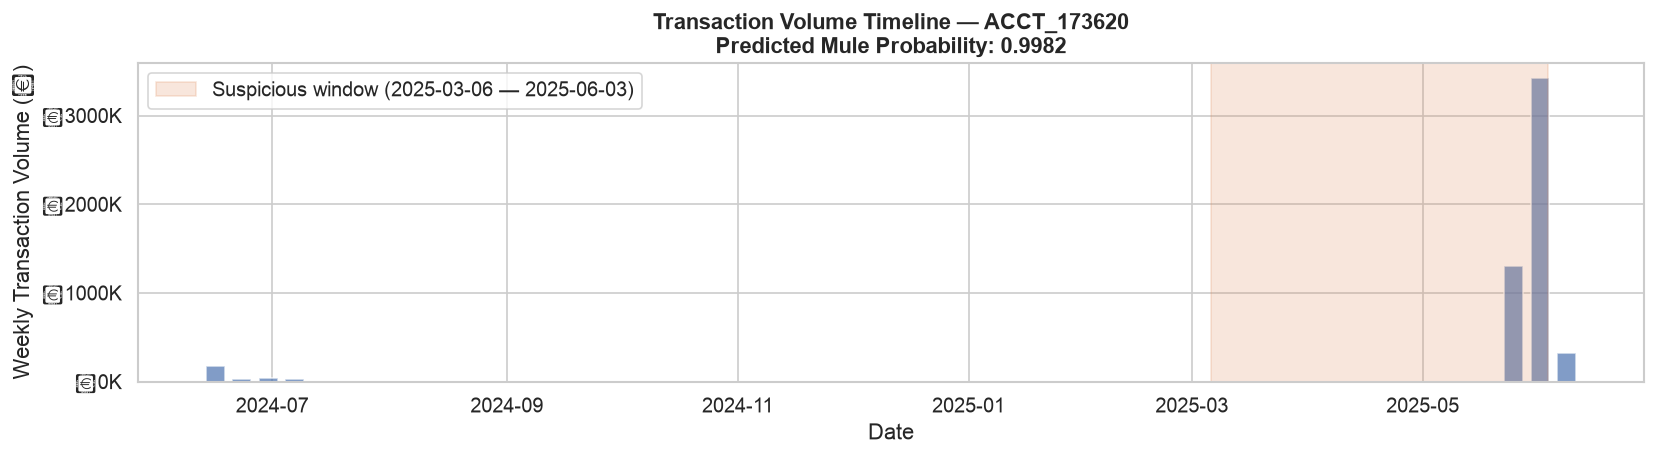

In [20]:
# Visualise transaction timeline for the top predicted mule
top_acct_id = top3_mules.iloc[0]['account_id']
acct_tx = transactions[transactions['account_id'] == top_acct_id].copy()
acct_tx = acct_tx.set_index('transaction_timestamp').sort_index()
daily_vol = acct_tx.resample('W')['amount'].sum()

window_row = windows_df[windows_df['account_id'] == top_acct_id].iloc[0]
win_start  = pd.Timestamp(window_row['suspicious_start'])
win_end    = pd.Timestamp(window_row['suspicious_end'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_vol.index, daily_vol.values, width=5, color='#4C72B0', alpha=0.7)
ax.axvspan(win_start, win_end, alpha=0.2, color='#DD8452',
           label=f'Suspicious window ({win_start.date()} — {win_end.date()})')
ax.set_title(f'Transaction Volume Timeline — {top_acct_id}\n'
             f'Predicted Mule Probability: {top3_mules.iloc[0]["oof_prob"]:.4f}',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Transaction Volume (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_suspicious_window.png', bbox_inches='tight')
plt.show()

---
## 9. Generate Final Test Predictions

In [21]:
# Ensemble: average predicted probabilities from all 5 fold models
test_probs = np.mean(
    [m.predict_proba(X_test)[:, 1] for m in fold_models], axis=0
)

# Compute suspicious windows for test accounts above high-risk threshold
test_df = test[['account_id']].copy()
test_df['mule_probability'] = test_probs

print('Computing suspicious windows for high-risk test accounts...')
test_windows = []
for _, row in test_df[test_df['mule_probability'] >= HIGH_RISK_THRESH].iterrows():
    start, end = detect_suspicious_window(row['account_id'], transactions)
    test_windows.append({'account_id': row['account_id'],
                         'suspicious_start': start, 'suspicious_end': end})

test_windows_df = pd.DataFrame(test_windows) if test_windows else pd.DataFrame(
    columns=['account_id','suspicious_start','suspicious_end'])

submission = test_df.merge(test_windows_df, on='account_id', how='left')
submission['suspicious_start'] = submission['suspicious_start'].fillna('')
submission['suspicious_end']   = submission['suspicious_end'].fillna('')

submission.to_csv(PRED_DIR + 'final_submission.csv', index=False)
print(f'Submission saved: {submission.shape}')
print(f'Predicted mules (prob >= 0.5): {(submission["mule_probability"] >= 0.5).sum()}')
display(submission.head(5))

Computing suspicious windows for high-risk test accounts...


Submission saved: (16015, 4)
Predicted mules (prob >= 0.5): 136


,account_id,mule_probability,suspicious_start,suspicious_end
0,ACCT_000077,0.0053,,
1,ACCT_000085,0.0004,,
2,ACCT_000156,0.0106,,
3,ACCT_000186,0.0132,,
4,ACCT_000222,0.0016,,


---
## 10. Results Summary

In [22]:
from sklearn.metrics import precision_score, recall_score
y_bin = (oof_preds >= best_t).astype(int)

print('=' * 60)
print('  MULE ACCOUNT DETECTION — FINAL RESULTS')
print('  RBI Innovation Hub')
print('=' * 60)
print(f'  Model           : LightGBM ({best_iter} trees, scale_pos_weight={scale_pos_weight:.0f})')
print(f'  Features        : {len(clean_feat_cols)} clean features (2 excluded for leakage)')
print(f'  Validation      : 5-fold stratified CV')
print()
print(f'  AUC-ROC (OOF)   : {oof_auc:.4f}')
print(f'  PR-AUC  (OOF)   : {pr_auc:.4f}')
print(f'  F1 @ t={best_t:.2f}   : {best_f1:.4f}')
print(f'  Precision @ t   : {precision_score(y, y_bin, zero_division=0):.4f}')
print(f'  Recall    @ t   : {recall_score(y, y_bin, zero_division=0):.4f}')
print()
print(f'  Top SHAP features (global):')
for feat, val in mean_abs_shap.sort_values(ascending=False).head(5).items():
    print(f'    {feat:<35} mean|SHAP|={val:.5f}')
print()
print(f'  Test predictions : {len(submission):,} accounts scored')
print(f'  Submission file  : data/predictions/final_submission.csv')
print('=' * 60)
print()
print('RESUME LINE:')
print(f'  "Engineered 31 behavioral/network/temporal features from 7.4M')
print(f'  banking transactions; trained LightGBM mule detector achieving')
print(f'  {oof_auc:.2f} AUC-ROC (RBI Innovation Hub)."')

  MULE ACCOUNT DETECTION — FINAL RESULTS
  RBI Innovation Hub
  Model           : LightGBM (261 trees, scale_pos_weight=90)
  Features        : 31 clean features (2 excluded for leakage)
  Validation      : 5-fold stratified CV

  AUC-ROC (OOF)   : 0.8572
  PR-AUC  (OOF)   : 0.3597
  F1 @ t=0.78   : 0.4308
  Precision @ t   : 0.5337
  Recall    @ t   : 0.3612

  Top SHAP features (global):
    tx_amount_30d                       mean|SHAP|=0.63800
    repeat_cp_ratio                     mean|SHAP|=0.54978
    round_amount_pct                    mean|SHAP|=0.47319
    channel_entropy                     mean|SHAP|=0.46730
    fan_out_unique                      mean|SHAP|=0.44520

  Test predictions : 16,015 accounts scored
  Submission file  : data/predictions/final_submission.csv

RESUME LINE:
  "Engineered 31 behavioral/network/temporal features from 7.4M
  banking transactions; trained LightGBM mule detector achieving
  0.86 AUC-ROC (RBI Innovation Hub)."
